In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats
from IPython.display import display

In [2]:
data = pd.read_csv("drug200.csv")

In [3]:
data.shape

(200, 6)

In [4]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [5]:
data.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [7]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [8]:
for i in data.columns.values.tolist():
    print(data[i].value_counts())

Age
47    8
23    7
28    7
49    7
39    6
32    6
50    5
37    5
58    5
60    5
22    5
34    4
72    4
51    4
42    4
26    4
24    4
74    4
67    4
68    4
61    4
56    4
20    4
36    4
45    4
41    4
31    4
43    4
65    4
57    4
53    3
40    3
70    3
59    3
16    3
38    3
15    3
69    3
35    3
18    3
64    3
52    2
55    2
62    2
19    2
29    2
66    2
73    2
46    2
48    2
54    1
17    1
33    1
63    1
30    1
21    1
25    1
Name: count, dtype: int64
Sex
M    104
F     96
Name: count, dtype: int64
BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64
Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64
Na_to_K
12.006    2
18.295    2
25.355    1
11.939    1
16.347    1
         ..
24.658    1
24.276    1
13.967    1
19.675    1
11.349    1
Name: count, Length: 198, dtype: int64
Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [10]:
missing_values = data.isnull()
for i in missing_values.columns.values.tolist():
    print(missing_values[i].value_counts())

Age
False    200
Name: count, dtype: int64
Sex
False    200
Name: count, dtype: int64
BP
False    200
Name: count, dtype: int64
Cholesterol
False    200
Name: count, dtype: int64
Na_to_K
False    200
Name: count, dtype: int64
Drug
False    200
Name: count, dtype: int64


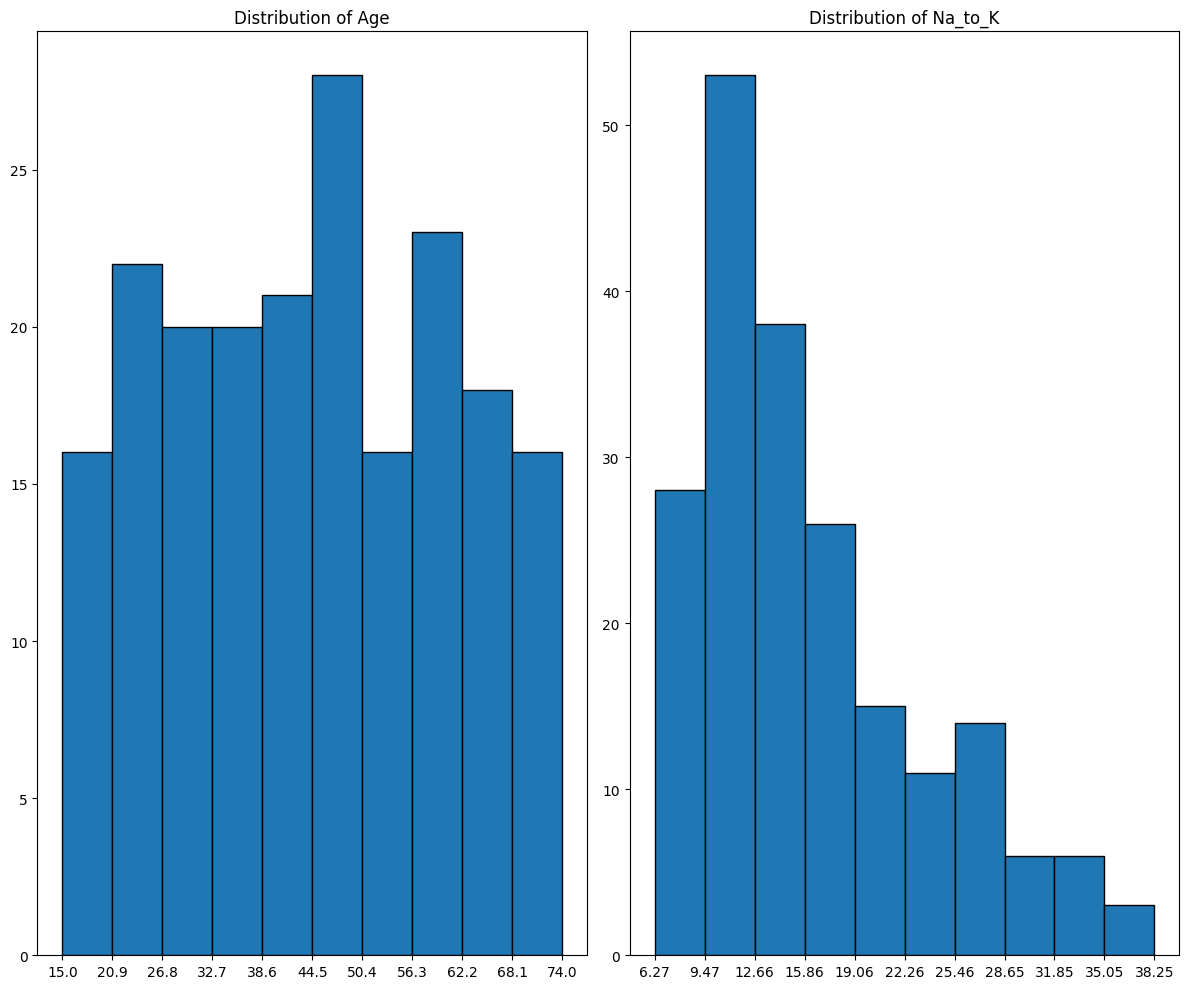

In [11]:
count, pin_edges = np.histogram(data["Age"])
count2, pin_edges2 = np.histogram(data["Na_to_K"])

fig, axes = plt.subplots(1, 2, figsize=(12, 10))

axes[0].hist(data["Age"], edgecolor="black")
axes[0].set_title("Distribution of Age")
axes[0].set_xticks(pin_edges)

axes[1].hist(data["Na_to_K"], edgecolor="black")
axes[1].set_title("Distribution of Na_to_K")
axes[1].set_xticks(pin_edges2)
plt.tight_layout()
plt.show()

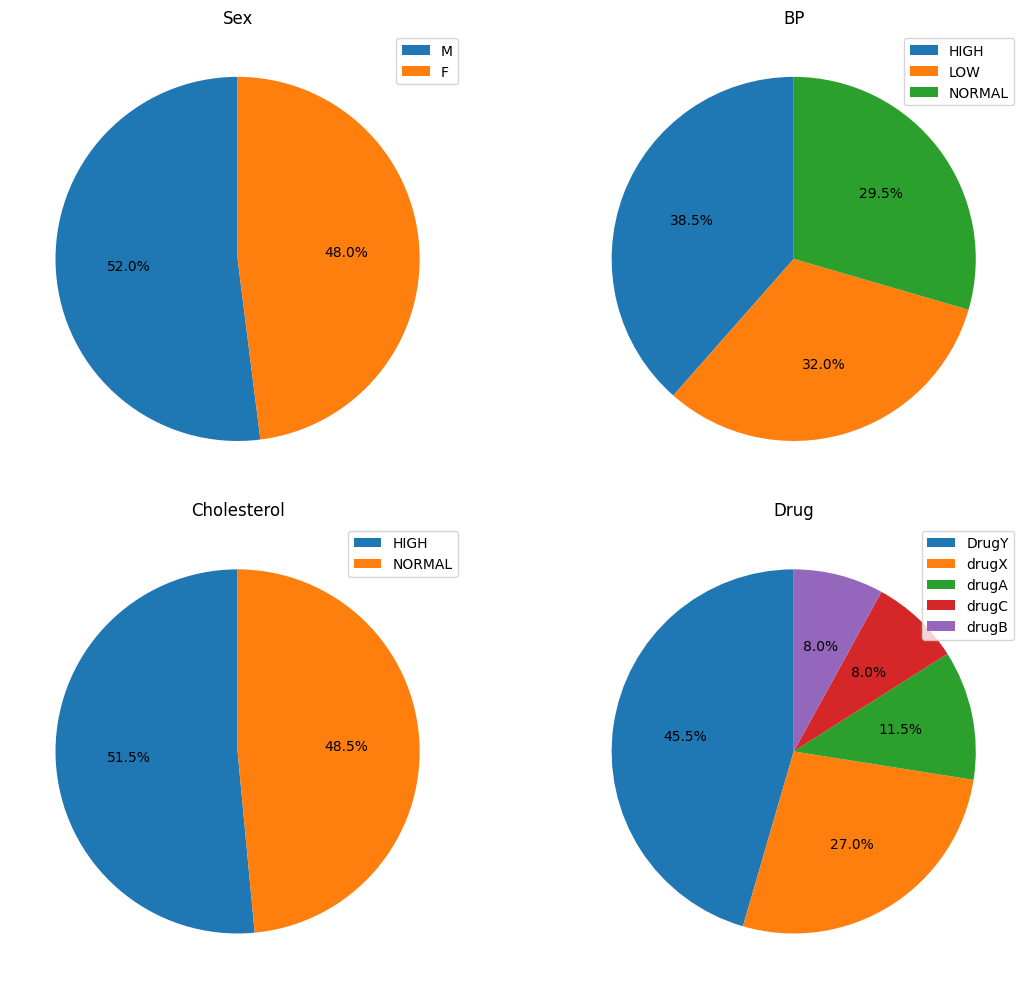

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))

axes[0, 0].pie((data["Sex"]).value_counts(),
               autopct='%1.1f%%',
               startangle=90)
axes[0, 0].set_title('Sex')
axes[0, 0].legend(labels = data["Sex"].value_counts().index, loc="upper right")

axes[0, 1].pie((data["BP"]).value_counts(),
               autopct='%1.1f%%',
               startangle=90)
axes[0, 1].set_title('BP')
axes[0, 1].legend(labels = data["BP"].value_counts().index, loc="upper right")

axes[1, 0].pie((data["Cholesterol"]).value_counts(),
               autopct='%1.1f%%',
               startangle=90)
axes[1, 0].set_title('Cholesterol')
axes[1, 0].legend(labels = data["Cholesterol"].value_counts().index, loc="upper right")

axes[1, 1].pie((data["Drug"]).value_counts(),
               autopct='%1.1f%%',
               startangle=90)
axes[1, 1].set_title('Drug')
axes[1, 1].legend(labels = data["Drug"].value_counts().index, loc="upper right")

plt.tight_layout()
plt.show()

Drug,DrugY,drugA,drugB,drugC,drugX
Na_to_K,22.37478,10.918783,11.524375,10.63375,10.650556


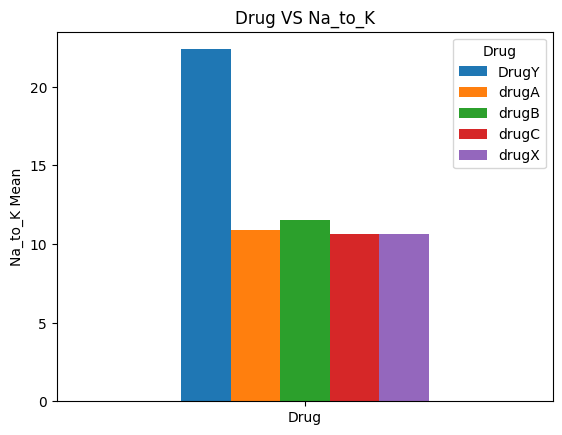

In [14]:
na_k_drug=data.groupby(["Drug"]).agg(
    Na_to_K = ("Na_to_K", "mean")
).reset_index()
na_k_drug.set_index("Drug", inplace=True)
na_k_drug = na_k_drug.transpose()
display(na_k_drug)

ax = na_k_drug.plot(kind="bar")
plt.title("Drug VS Na_to_K")
ax.set_xticks([0])
ax.set_xticklabels(["Drug"])
plt.xticks(rotation=0)
plt.ylabel("Na_to_K Mean")
plt.show()

In [15]:
drug_sex = data.groupby(["Drug", "Sex"]).agg(
    Gender = ("Sex", "size")
).reset_index()
pivot_drug_sex = drug_sex.pivot(index = "Drug", columns ="Sex")
pivot_drug_sex = pivot_drug_sex.div(pivot_drug_sex.sum(axis=1), axis=0) * 100

drug_BP = data.groupby(["Drug", "BP"]).agg(
    bp = ("BP", "size")
).reset_index()
pivot_drug_BP = drug_BP.pivot(index = "Drug", columns ="BP")
pivot_drug_BP = pivot_drug_BP.div(pivot_drug_BP.sum(axis=1), axis=0) * 100
pivot_drug_BP.replace(np.nan,0,inplace=True)    

drug_cho = data.groupby(["Drug", "Cholesterol"]).agg(
    cholesterol = ("Cholesterol", "size")
).reset_index()
pivot_drug_cho= drug_cho.pivot(index = "Drug", columns ="Cholesterol")
pivot_drug_cho = pivot_drug_cho.div(pivot_drug_cho.sum(axis=1), axis=0) * 100
pivot_drug_cho.replace(np.nan,0,inplace=True)    

display(pivot_drug_sex)
display(pivot_drug_BP)
display(pivot_drug_cho)


Gender           
Sex            F          M
Drug                       
DrugY  51.648352  48.351648
drugA  39.130435  60.869565
drugB  37.500000  62.500000
drugC  43.750000  56.250000
drugX  50.000000  50.000000

bp                       
BP           HIGH         LOW     NORMAL
Drug                                    
DrugY   41.758242   32.967033  25.274725
drugA  100.000000    0.000000   0.000000
drugB  100.000000    0.000000   0.000000
drugC    0.000000  100.000000   0.000000
drugX    0.000000   33.333333  66.666667

cholesterol           
Cholesterol        HIGH     NORMAL
Drug                              
DrugY         51.648352  48.351648
drugA         52.173913  47.826087
drugB         50.000000  50.000000
drugC        100.000000   0.000000
drugX         37.037037  62.962963

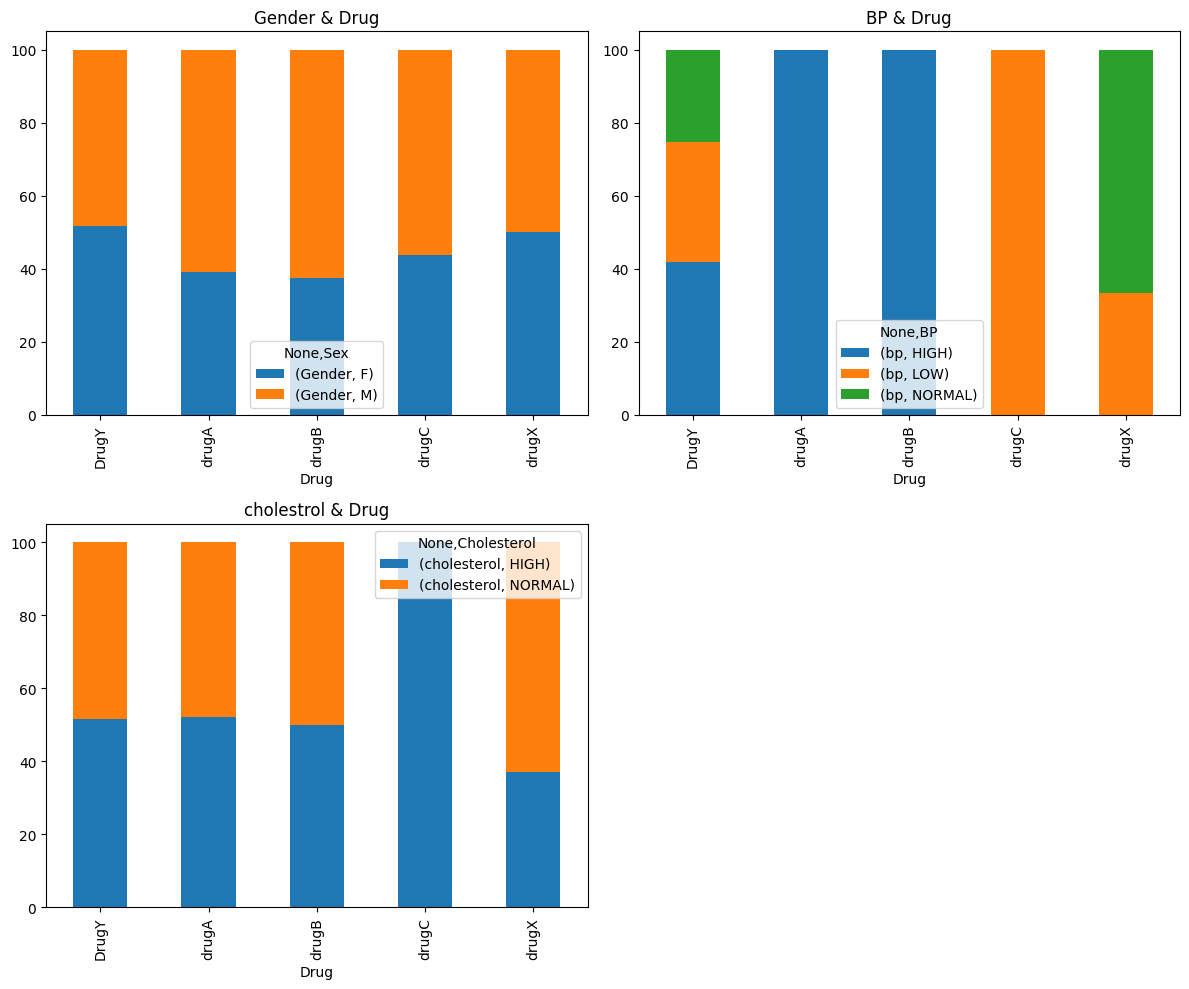

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pivot_drug_sex.plot(kind="bar", stacked=True, ax=axes[0, 0])
pivot_drug_BP.plot(kind="bar", stacked=True, ax=axes[0, 1])
pivot_drug_cho.plot(kind="bar", stacked=True, ax=axes[1, 0])
axes[0, 0].set_title("Gender & Drug")
axes[0, 1].set_title("BP & Drug")
axes[1, 0].set_title("cholestrol & Drug")

fig.delaxes(axes[1, 1])
plt.tight_layout()
plt.show()

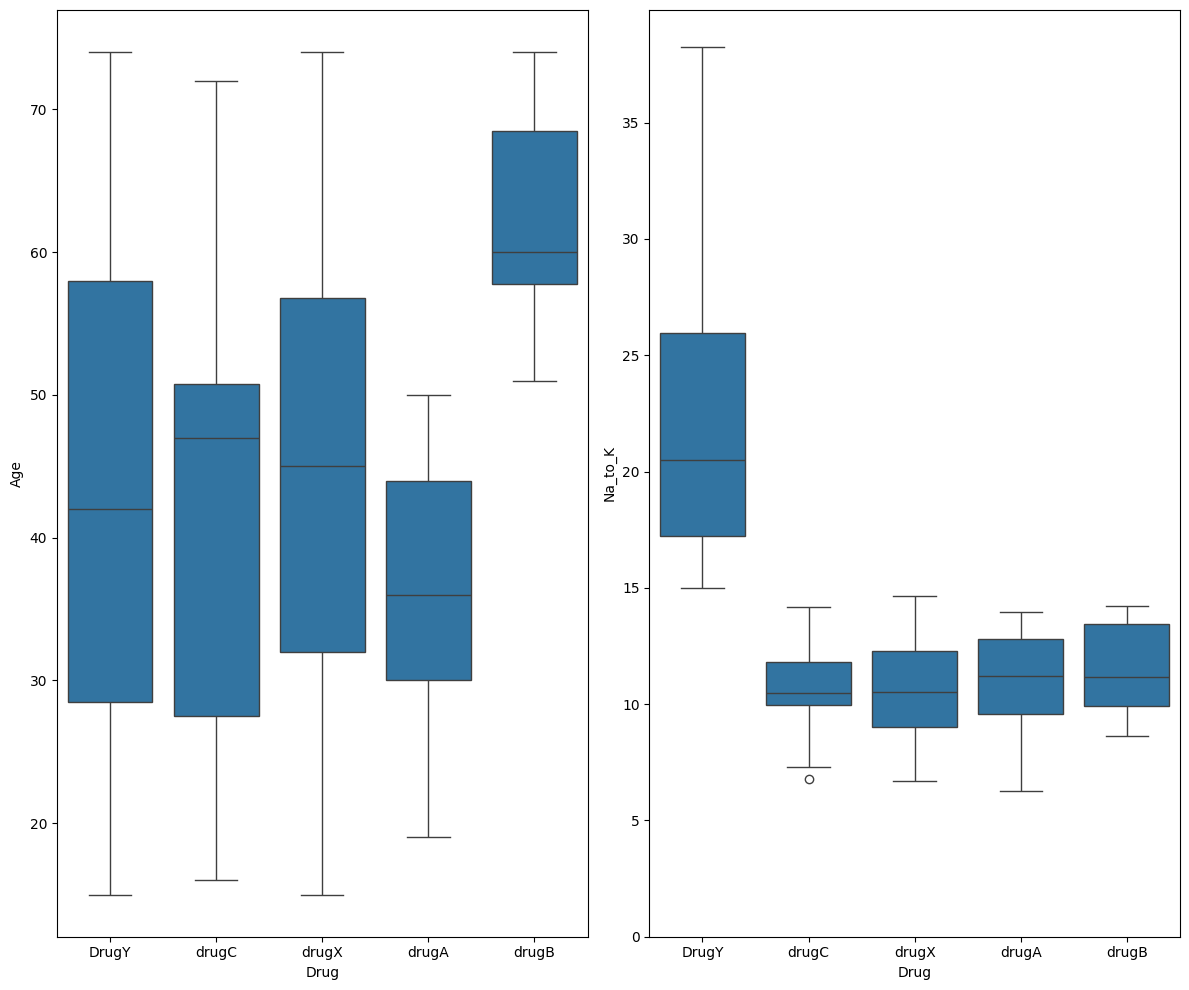

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
sns.boxplot(x="Drug", y="Age", data=data, ax=axes[0])
sns.boxplot(x="Drug", y="Na_to_K", data=data, ax=axes[1])

plt.tight_layout()
plt.ylim(0, )
plt.show()

In [20]:
from scipy.stats import chi2, chi2_contingency

results = []

categorical_columns = data.drop("Drug", axis=1).select_dtypes(include=['object']).columns  

for col in categorical_columns.tolist():
    contingency_table = pd.crosstab(data[col], data['Drug'])
    
    chi2_value, p, dof, expected = chi2_contingency(contingency_table)
    
    alpha = 0.05
    critical_value = chi2.ppf(1 - alpha, dof)
    
    relation = "YES ✅" if chi2_value > critical_value else "NO ❌"
    
    results.append([col, chi2_value, p, dof, critical_value, relation])

chi2_results_df = pd.DataFrame(results, columns=["Feature", "Chi-Square Value", "P-Value", "DOF", "Critical Value", "Relation"])

chi2_results_df

,Feature,Chi-Square Value,P-Value,DOF,Critical Value,Relation
0,Sex,2.119248,7.138370e-01,4,9.487729,NO ❌
1,BP,143.232872,5.041733e-27,8,15.507313,YES ✅
2,Cholesterol,19.609658,5.962588e-04,4,9.487729,YES ✅


In [21]:
X = data.drop("Drug", axis=1)
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


In [22]:
y = data["Drug"]
y.head()

0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)
y

array([0, 3, 3, 4, 0, 4, 0, 3, 0, 0, 3, 0, 0, 0, 4, 0, 4, 1, 3, 0, 0, 0,
       0, 0, 0, 0, 0, 4, 0, 0, 4, 2, 4, 0, 4, 4, 1, 4, 4, 4, 0, 2, 0, 4,
       4, 4, 1, 3, 0, 0, 0, 4, 0, 0, 2, 3, 2, 0, 4, 0, 0, 1, 0, 4, 2, 0,
       1, 4, 0, 0, 2, 0, 4, 0, 0, 0, 1, 0, 1, 4, 2, 4, 3, 1, 3, 2, 4, 0,
       0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 1, 1, 3, 4, 0, 4, 4, 0, 2, 0,
       1, 4, 4, 4, 4, 0, 4, 4, 1, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0, 4, 0, 0,
       4, 0, 0, 4, 2, 1, 2, 4, 1, 0, 2, 0, 1, 4, 4, 1, 4, 3, 1, 2, 4, 4,
       0, 3, 1, 0, 3, 4, 4, 2, 4, 0, 0, 0, 0, 4, 0, 1, 4, 4, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 4, 4, 0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 3, 0, 3, 3, 4,
       4, 4])

In [24]:
scalar = StandardScaler()
num = X.select_dtypes(exclude=["object"]).columns.tolist()
X[num] = scalar.fit_transform(X[num])
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,-1.291591,F,HIGH,HIGH,1.286522
1,0.162699,M,LOW,HIGH,-0.415145
2,0.162699,M,LOW,HIGH,-0.828558
3,-0.988614,F,NORMAL,HIGH,-1.149963
4,1.011034,F,LOW,HIGH,0.271794


In [25]:
cat_feat = X.select_dtypes(include=["object"])
X = pd.get_dummies(X, columns=cat_feat.columns.tolist())
X.head()

,Age,Na_to_K,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,-1.291591,1.286522,True,False,True,False,False,True,False
1,0.162699,-0.415145,False,True,False,True,False,True,False
2,0.162699,-0.828558,False,True,False,True,False,True,False
3,-0.988614,-1.149963,True,False,False,False,True,True,False
4,1.011034,0.271794,True,False,False,True,False,True,False


In [26]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [28]:
y_pred = model.predict(x_test)
y_org = encoder.inverse_transform(y_pred)
y_org

array(['drugX', 'drugA', 'drugX', 'drugC', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'drugA', 'drugX', 'drugA', 'drugX', 'DrugY', 'drugA',
       'drugB', 'DrugY', 'drugB', 'drugX', 'drugC', 'DrugY', 'drugB',
       'drugX', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugC', 'drugX',
       'DrugY', 'drugX', 'DrugY', 'drugC', 'drugC', 'DrugY', 'drugA',
       'DrugY', 'drugX', 'drugA', 'DrugY', 'drugA'], dtype=object)

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acccuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acccuracy * 100:4f}%")

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("Classification Report")
print(class_report)

Accuracy: 97.500000%
Confusion Matrix
[[14  1  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0 11]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           0.97        40
   macro avg       0.97      0.99      0.98        40
weighted avg       0.98      0.97      0.98        40



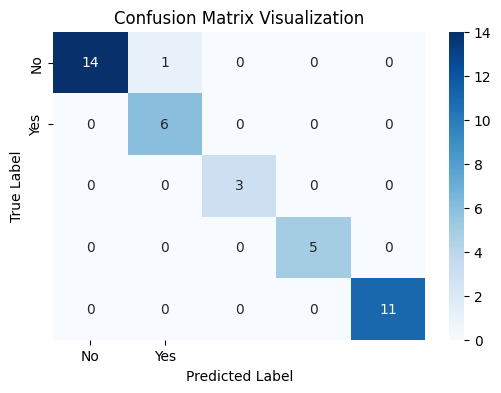

In [33]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Visualization")
plt.show()